In [194]:
# CNN (MobileNet) for Plant Disease Detection:
#The goal of this study is to apply deep learning to diagnose plant leaf diseases.
#The goal is to use a pretrained MobileNet architecture to create an accurate and effective image categorization model.
#This model lowers manual inspection errors, increases agricultural productivity, and aids in the early detection of plant diseases.

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [195]:
## Dataset Description

import zipfile
import os

# Enter the directory where the zip file should be extracted and its path
compressed_file = '/content/drive/MyDrive/Colab Notebooks/archive.zip'
destination_folder = '/content/'

# Opening the zip file and extracting all the required contents to the specified directory
with zipfile.ZipFile(compressed_file, 'r') as zip_handler:
    zip_handler.extractall(destination_folder)


In [196]:
# Importing the TensorFlow libraries
import tensorflow as tf
from tensorflow import keras

# Visualization libraries
import matplotlib.pyplot as plt
import numpy as np

# Operating the system utilities
import os


In [197]:
# dimensions of the image
img_dimension = 224
img_target_dim = (img_dimension, img_dimension)
img_input_shape = (img_dimension, img_dimension, 3)

# Training the parameters
train_batch_size = 32
num_epochs = 25


In [198]:
base_dir = "/content/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)"
train_dir = os.path.join(base_dir,"train")
test_dir = os.path.join(base_dir,"valid")

In [199]:
## Augmenting Data
train_image_gen = keras.preprocessing.image.ImageDataGenerator(
    rescale=1/255.0,
    shear_range=0.2,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    fill_mode="nearest"
)

# data preprocessing the image for testing (no augmentation)
test_image_gen = keras.preprocessing.image.ImageDataGenerator(
    rescale=1/255.0
)


In [200]:
# Loading and augmenting training images from the directory
train_dataset = train_image_gen.flow_from_directory(
    train_dir,
    target_size=img_target_dim,
    batch_size=train_batch_size,
    class_mode="categorical"
)

# Without augmentation, Loading the test images from directory
test_dataset = test_image_gen.flow_from_directory(
    test_dir,
    target_size=img_target_dim,
    batch_size=train_batch_size,
    class_mode="categorical"
)


Found 70295 images belonging to 38 classes.
Found 17572 images belonging to 38 classes.


In [201]:
# class labels are extracted from the training dataset
class_labels = list(train_dataset.class_indices.keys())
print("Class Indices:", train_dataset.class_indices)


Class Indices: {'Apple___Apple_scab': 0, 'Apple___Black_rot': 1, 'Apple___Cedar_apple_rust': 2, 'Apple___healthy': 3, 'Blueberry___healthy': 4, 'Cherry_(including_sour)___Powdery_mildew': 5, 'Cherry_(including_sour)___healthy': 6, 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot': 7, 'Corn_(maize)___Common_rust_': 8, 'Corn_(maize)___Northern_Leaf_Blight': 9, 'Corn_(maize)___healthy': 10, 'Grape___Black_rot': 11, 'Grape___Esca_(Black_Measles)': 12, 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)': 13, 'Grape___healthy': 14, 'Orange___Haunglongbing_(Citrus_greening)': 15, 'Peach___Bacterial_spot': 16, 'Peach___healthy': 17, 'Pepper,_bell___Bacterial_spot': 18, 'Pepper,_bell___healthy': 19, 'Potato___Early_blight': 20, 'Potato___Late_blight': 21, 'Potato___healthy': 22, 'Raspberry___healthy': 23, 'Soybean___healthy': 24, 'Squash___Powdery_mildew': 25, 'Strawberry___Leaf_scorch': 26, 'Strawberry___healthy': 27, 'Tomato___Bacterial_spot': 28, 'Tomato___Early_blight': 29, 'Tomato___Late_bligh

In [202]:
import json

# The class indices are saved in a JSON file.
with open('class_indices.json', 'w') as json_file:
    json.dump(train_dataset.class_indices, json_file)

# Providing a download link for the JSON file (Colab/Jupyter)
from IPython.display import FileLink
display(FileLink('class_indices.json'))


/content/class_indices.json

In [203]:
# Initializing the MobileNet pre-trained model (excluding top layers)
pretrained_base_model = tf.keras.applications.MobileNet(
    weights="imagenet",
    include_top=False,
    input_shape=img_input_shape
)

# Freezing the pre-trained model layers
pretrained_base_model.trainable = False


17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [204]:
# Defining the input layer
input_layer = keras.Input(shape=img_input_shape)

# Passing the inputs through the pretrained MobileNet base model
x = pretrained_base_model(input_layer, training=False)

# Adding Global Average Pooling layer
x = tf.keras.layers.GlobalAveragePooling2D()(x)

# Adding the Dropout for regularization
x = tf.keras.layers.Dropout(0.2)(x)

# Adding the final Dense layer for classification
output_layer = tf.keras.layers.Dense(
    len(class_labels),
    activation="softmax"
)(x)

# Defining the full model
plant_disease_model = keras.Model(
    inputs=input_layer,
    outputs=output_layer,
    name="LeafDisease_MobileNet"
)


In [205]:
# Defining the optimizer
model_optimizer = tf.keras.optimizers.Adam()

# Compiling the model
plant_disease_model.compile(
    optimizer=model_optimizer,
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=True),
    metrics=[
        keras.metrics.CategoricalAccuracy(),
        'accuracy'
    ]
)


In [206]:
# Training the model
training_history = plant_disease_model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=num_epochs,
    steps_per_epoch=150,
    validation_steps=100
)


Epoch 1/25
150/150 ━━━━━━━━━━━━━━━━━━━━ 75s 483ms/step - accuracy: 0.2960 - categorical_accuracy: 0.2960 - loss: 2.7695 - val_accuracy: 0.8147 - val_categorical_accuracy: 0.8147 - val_loss: 0.7866
Epoch 2/25
150/150 ━━━━━━━━━━━━━━━━━━━━ 71s 473ms/step - accuracy: 0.7720 - categorical_accuracy: 0.7720 - loss: 0.8222 - val_accuracy: 0.8625 - val_categorical_accuracy: 0.8625 - val_loss: 0.4832
Epoch 3/25
150/150 ━━━━━━━━━━━━━━━━━━━━ 70s 472ms/step - accuracy: 0.8295 - categorical_accuracy: 0.8295 - loss: 0.5855 - val_accuracy: 0.8856 - val_categorical_accuracy: 0.8856 - val_loss: 0.3952
Epoch 4/25
150/150 ━━━━━━━━━━━━━━━━━━━━ 69s 460ms/step - accuracy: 0.8597 - categorical_accuracy: 0.8597 - loss: 0.4883 - val_accuracy: 0.8991 - val_categorical_accuracy: 0.8991 - val_loss: 0.3421
Epoch 5/25
150/150 ━━━━━━━━━━━━━━━━━━━━ 68s 452ms/step - accuracy: 0.8750 - categorical_accuracy: 0.8750 - loss: 0.4239 - val_accuracy: 0.9062 - val_categorical_accuracy: 0.9062 - val_loss: 0.3011
Epoch 6/25
150/

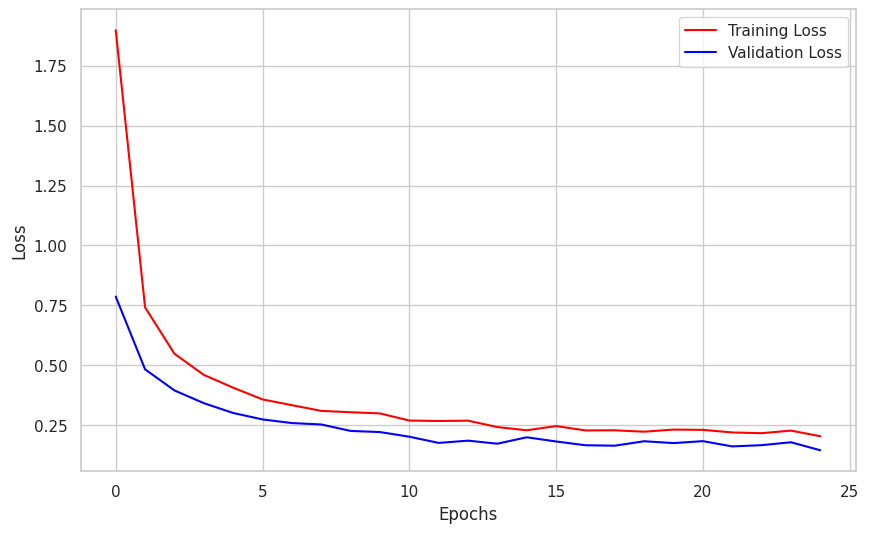

In [207]:
# Extracting the loss values
training_loss = training_history.history['loss']
validation_loss = training_history.history['val_loss']

# Defining the range of epochs
epoch_range = range(len(training_loss))

# Plotting the training and validation loss
fig = plt.figure(figsize=(10, 6))
plt.plot(epoch_range, training_loss, c="red", label="Training Loss")
plt.plot(epoch_range, validation_loss, c="blue", label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()


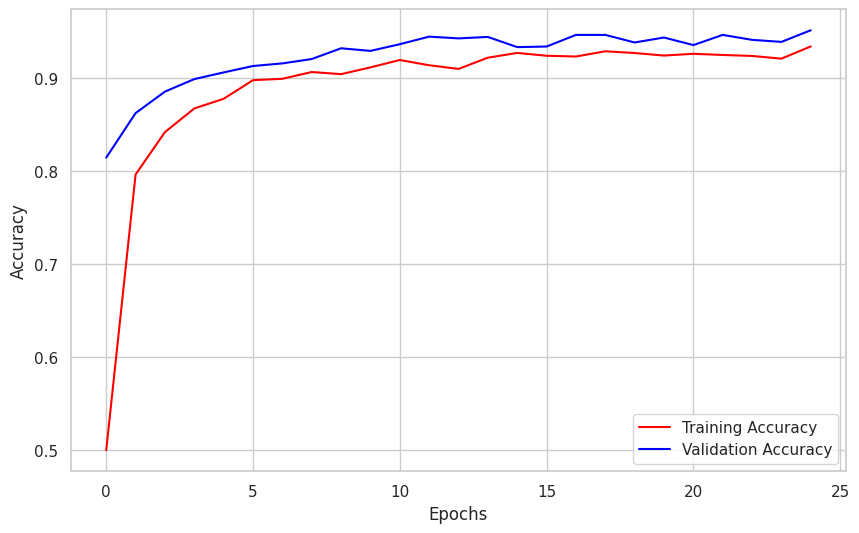

In [208]:
# Extracting the accuracy values
training_accuracy = training_history.history['categorical_accuracy']
validation_accuracy = training_history.history['val_categorical_accuracy']

# Defining the range of epochs
epoch_range_acc = range(len(training_accuracy))

# Plotting the training and validation accuracy
fig = plt.figure(figsize=(10, 6))
plt.plot(epoch_range_acc, training_accuracy, c="red", label="Training Accuracy")
plt.plot(epoch_range_acc, validation_accuracy, c="blue", label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()


In [210]:
# Using the.keras extension to save the trained model
plant_disease_model.save('plant_disease.keras')

In [211]:
import tensorflow as tf

# The trained model should be converted to TensorFlow Lite format
model_converter = tf.lite.TFLiteConverter.from_keras_model(plant_disease_model)
tflite_converted_model = model_converter.convert()

# TensorFlow Lite model saving it in to a file
with open('plant_disease_model.tflite', 'wb') as file:
    file.write(tflite_converted_model)


Saved artifact at '/tmp/tmpkyu4ild3'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_86')
Output Type:
  TensorSpec(shape=(None, 38), dtype=tf.float32, name=None)
Captures:
  133789908326288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133789908327440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133789908327824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133789908327056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133789908326096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133787148806160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133789908326672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133789908325136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133789908328400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133789908327632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1337899083